<a href="https://colab.research.google.com/github/Aryamaan777/Finance/blob/BasicML/BasicML/Tree_Based_Models_for_Returns.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import precision_score
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

In [ ]:
# --- 1. DATA LOADING & ENGINEERING ---
ticker = 'SPY'
print(f"Downloading data for {ticker}...")
df = yf.download(ticker, start='2010-01-01', end='2024-01-01', progress=False)
if isinstance(df.columns, pd.MultiIndex): df.columns = df.columns.get_level_values(0)

# Feature Engineering (Condensed)
df['Log_Ret'] = np.log(df['Close'] / df['Close'].shift(1))
df['Vol_20'] = df['Log_Ret'].rolling(20).std()
df['Mom_20'] = df['Close'].pct_change(20)
df['Mom_50'] = df['Close'].pct_change(50)
# Distance from Moving Average (Mean Reversion)
df['Dist_MA200'] = (df['Close'] - df['Close'].rolling(200).mean()) / df['Close'].rolling(200).mean()
# Shadows (Price Action)
df['Upper_Shadow'] = df['High'] - df[['Open', 'Close']].max(axis=1)

# Target: 1 if Return > 0 (Next Day)
df['Target'] = np.where(df['Log_Ret'].shift(-1) > 0, 1, 0)

df.dropna(inplace=True)
print(f"Data ready: {len(df)} trading days.")

/tmp/ipython-input-2806727699.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start='2010-01-01', end='2024-01-01', progress=False)


Data ready: 3323 trading days.


In [ ]:
def walk_forward_validation(model_class, params, data, train_window=1000, step_size=60):
    """
    Simulates a rolling trading strategy.

    Args:
        model_class: The class of the model (e.g., XGBClassifier)
        params: Dictionary of hyperparameters
        data: DataFrame with features and target
        train_window: Number of past days to train on (e.g., 1000 days ~= 4 years)
        step_size: How often to retrain (e.g., 60 days = every 3 months)

    Returns:
        DataFrame containing Date, Actual, Prediction, Probability
    """
    results = []

    # We step through the data
    # Start at 'train_window' and move forward by 'step_size'
    for i in range(train_window, len(data), step_size):
        # Define the Sliding Window
        train_data = data.iloc[i-train_window : i]
        test_data = data.iloc[i : i+step_size]

        if len(test_data) == 0: break

        # Split X and y
        X_train = train_data.drop(['Target', 'Log_Ret'], axis=1)
        y_train = train_data['Target']
        X_test = test_data.drop(['Target', 'Log_Ret'], axis=1)
        y_test = test_data['Target'] # For evaluation

        # Initialize and Train Model
        model = model_class(**params)
        model.fit(X_train, y_train)

        # Predict
        preds = model.predict(X_test)
        probs = model.predict_proba(X_test)[:, 1]

        # Store Results
        chunk_res = pd.DataFrame({
            'Date': test_data.index,
            'Actual': y_test.values,
            'Pred': preds,
            'Prob': probs,
            'Return': test_data['Log_Ret'].values
        })
        results.append(chunk_res)

    return pd.concat(results).set_index('Date')

In [ ]:
# --- CONTENDERS ---
models = {
    "Decision Tree": (DecisionTreeClassifier, {'max_depth': 3, 'random_state': 42}),
    "Random Forest": (RandomForestClassifier, {'n_estimators': 100, 'max_depth': 3, 'random_state': 42}),
    "XGBoost": (XGBClassifier, {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.1, 'random_state': 42, 'eval_metric': 'logloss'})
}

equity_curves = {}
rolling_accuracies = {}

print("Starting Walk-Forward Validation (This may take a moment)...")

for name, (model_cls, params) in models.items():
    print(f"Training {name}...")
    res = walk_forward_validation(model_cls, params, df, train_window=2000, step_size=63) # Retrain every quarter

    # Strategy: Long if Pred=1, Cash if Pred=0 (No Shorting for simplicity)
    # We use a slight probability threshold for stability (> 0.52)
    res['Signal'] = np.where(res['Prob'] > 0.52, 1, 0)
    res['Strat_Ret'] = res['Signal'] * res['Return']

    # Cumulative Return
    equity_curves[name] = res['Strat_Ret'].cumsum()

    # Rolling Accuracy (6-month moving average of correctness)
    res['Correct'] = (res['Pred'] == res['Actual']).astype(int)
    rolling_accuracies[name] = res['Correct'].rolling(126).mean()

# Benchmark (Buy & Hold) - aligned to the start of the test period
start_date = equity_curves["XGBoost"].index[0]
benchmark = df.loc[start_date:]['Log_Ret'].cumsum()

print("Battle Complete.")

Starting Walk-Forward Validation (This may take a moment)...
Training Decision Tree...
Training Random Forest...
Training XGBoost...
Battle Complete.


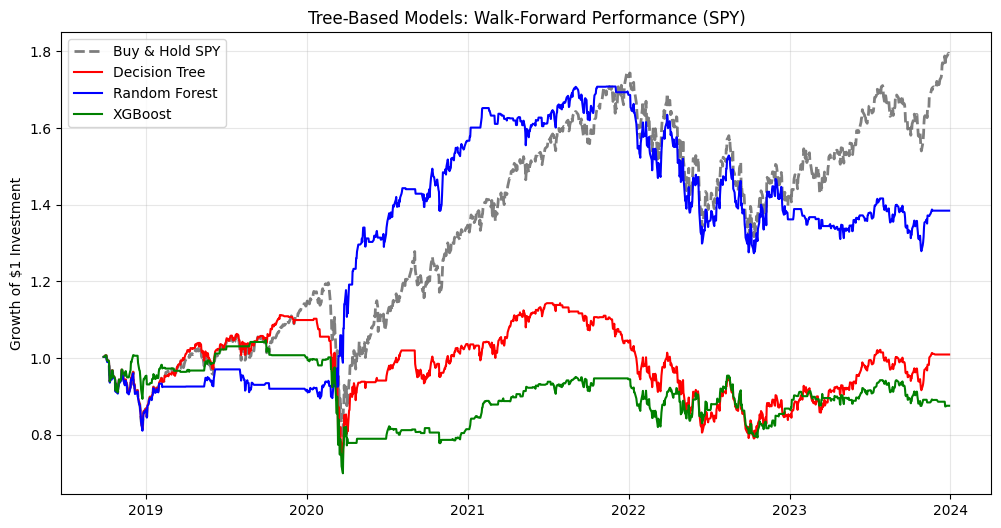

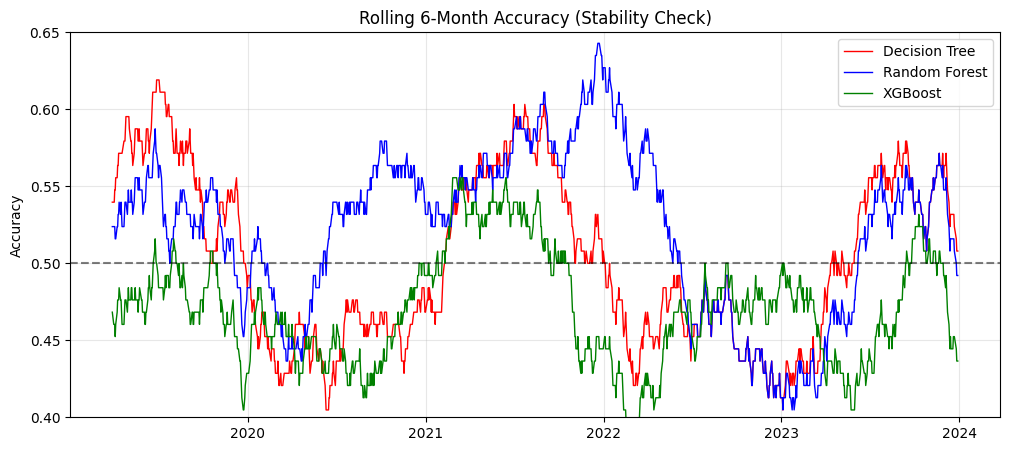

In [ ]:
# --- PLOT 1: Cumulative Returns ---
plt.figure(figsize=(12, 6))
plt.plot(np.exp(benchmark), label='Buy & Hold SPY', color='black', linestyle='--', alpha=0.5, linewidth=2)

colors = {'Decision Tree': 'red', 'Random Forest': 'blue', 'XGBoost': 'green'}

for name, curve in equity_curves.items():
    plt.plot(np.exp(curve), label=name, color=colors[name], linewidth=1.5)

plt.title("Tree-Based Models: Walk-Forward Performance (SPY)")
plt.ylabel("Growth of $1 Investment")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- PLOT 2: Rolling Accuracy (Model Stability) ---
plt.figure(figsize=(12, 5))

for name, acc in rolling_accuracies.items():
    plt.plot(acc, label=name, color=colors[name], linewidth=1)

plt.axhline(0.5, color='black', linestyle='--', alpha=0.5)
plt.title("Rolling 6-Month Accuracy (Stability Check)")
plt.ylabel("Accuracy")
plt.ylim(0.40, 0.65) # Zoom in on the critical 50% line
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

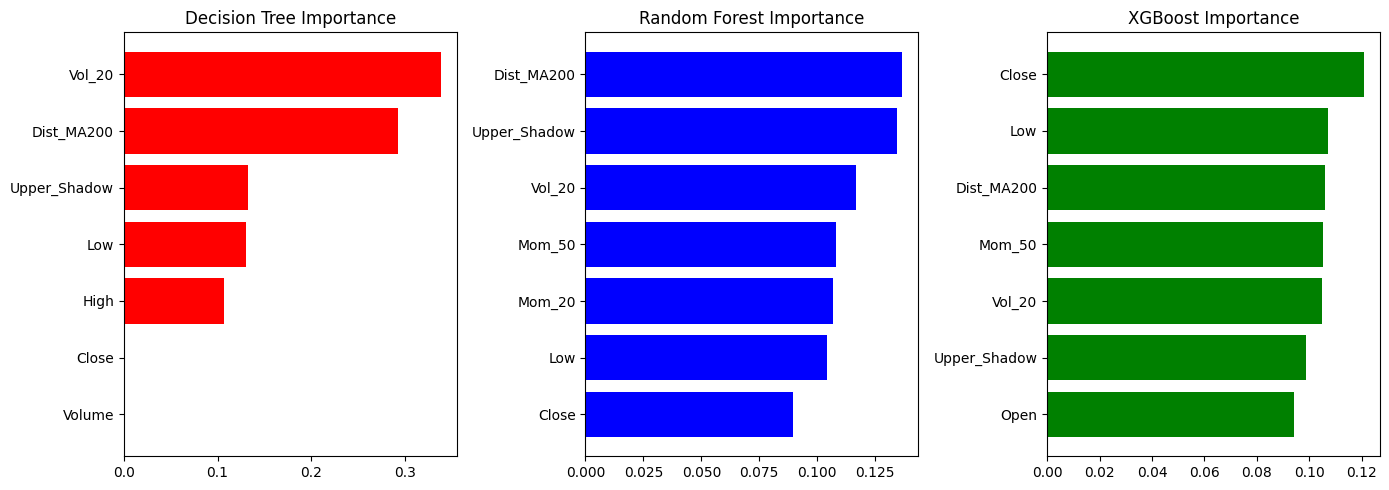

In [ ]:
# --- 1. EXTRACT FEATURE IMPORTANCE ---
# We assume 'models' and 'df' are still loaded from the previous step.
# We fit each model on the LAST 2000 days to see their current "state of mind".

last_window_data = df.iloc[-2000:]
X_last = last_window_data.drop(['Target', 'Log_Ret'], axis=1)
y_last = last_window_data['Target']

feature_names = X_last.columns
importance_data = []

plt.figure(figsize=(14, 5))

for i, (name, (model_cls, params)) in enumerate(models.items()):
    # Train fresh model on recent data
    model = model_cls(**params)
    model.fit(X_last, y_last)

    # Extract importances
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    else:
        # Fallback for models without direct feature_importance_ (rare in trees)
        importances = np.zeros(len(feature_names))

    # Create DataFrame for sorting
    feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    feat_df = feat_df.sort_values(by='Importance', ascending=False).head(7) # Top 7 only

    # Plot
    plt.subplot(1, 3, i+1)
    plt.barh(feat_df['Feature'], feat_df['Importance'], color=['red', 'blue', 'green'][i])
    plt.title(f"{name} Importance")
    plt.gca().invert_yaxis() # Highest importance on top

plt.tight_layout()
plt.show()

In [ ]:
# --- 1. DEFINE THE GRID ---
# What hyperparameters do we want to test?
xgb_param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [2, 3, 4],
    'learning_rate': [0.01, 0.1]
}

In [ ]:
# --- 2. THE SELF-TUNING ENGINE ---
def walk_forward_grid_search(model_class, param_grid, data, train_window=1000, step_size=63):
    results = []
    best_params_history = []

    # We step through the data
    for i in range(train_window, len(data), step_size):
        # 1. Define Windows
        train_data = data.iloc[i-train_window : i]
        test_data = data.iloc[i : i+step_size]

        if len(test_data) == 0: break

        X_train_full = train_data.drop(['Target', 'Log_Ret'], axis=1)
        y_train_full = train_data['Target']
        X_test = test_data.drop(['Target', 'Log_Ret'], axis=1)
        y_test = test_data['Target']

        # 2. INNER GRID SEARCH (Auto-Tuning)
        # We split the 'train_data' into inner train/val sets using TimeSeriesSplit
        # This prevents looking into the future during tuning
        tscv = TimeSeriesSplit(n_splits=3)

        grid = GridSearchCV(
            estimator=model_class(random_state=42, eval_metric='logloss'),
            param_grid=param_grid,
            cv=tscv,
            scoring='accuracy', # Or 'precision' if you want to be conservative
            n_jobs=-1
        )

        grid.fit(X_train_full, y_train_full)

        # 3. USE BEST MODEL
        best_model = grid.best_estimator_
        best_params_history.append({'Date': test_data.index[0], 'Params': grid.best_params_})

        # Predict on the unseen test block
        preds = best_model.predict(X_test)
        probs = best_model.predict_proba(X_test)[:, 1]

        # Store
        chunk_res = pd.DataFrame({
            'Date': test_data.index,
            'Actual': y_test.values,
            'Pred': preds,
            'Prob': probs,
            'Return': test_data['Log_Ret'].values
        })
        results.append(chunk_res)

        # Optional: Print progress every few years
        if i % (step_size * 4) == 0:
            print(f"Date: {test_data.index[0].date()} | Best Params: {grid.best_params_}")

    return pd.concat(results).set_index('Date'), pd.DataFrame(best_params_history).set_index('Date')

In [ ]:
# --- 3. RUN THE SIMULATION ---
print("Starting Self-Optimizing XGBoost (This takes time)...")

# We reduce the train window slightly to speed up the tutorial,
# but in real life, use 1000+ days.
tuned_res, params_log = walk_forward_grid_search(
    XGBClassifier,
    xgb_param_grid,
    df,
    train_window=1000,
    step_size=63
)

print("Simulation Complete.")

Starting Self-Optimizing XGBoost (This takes time)...
Simulation Complete.


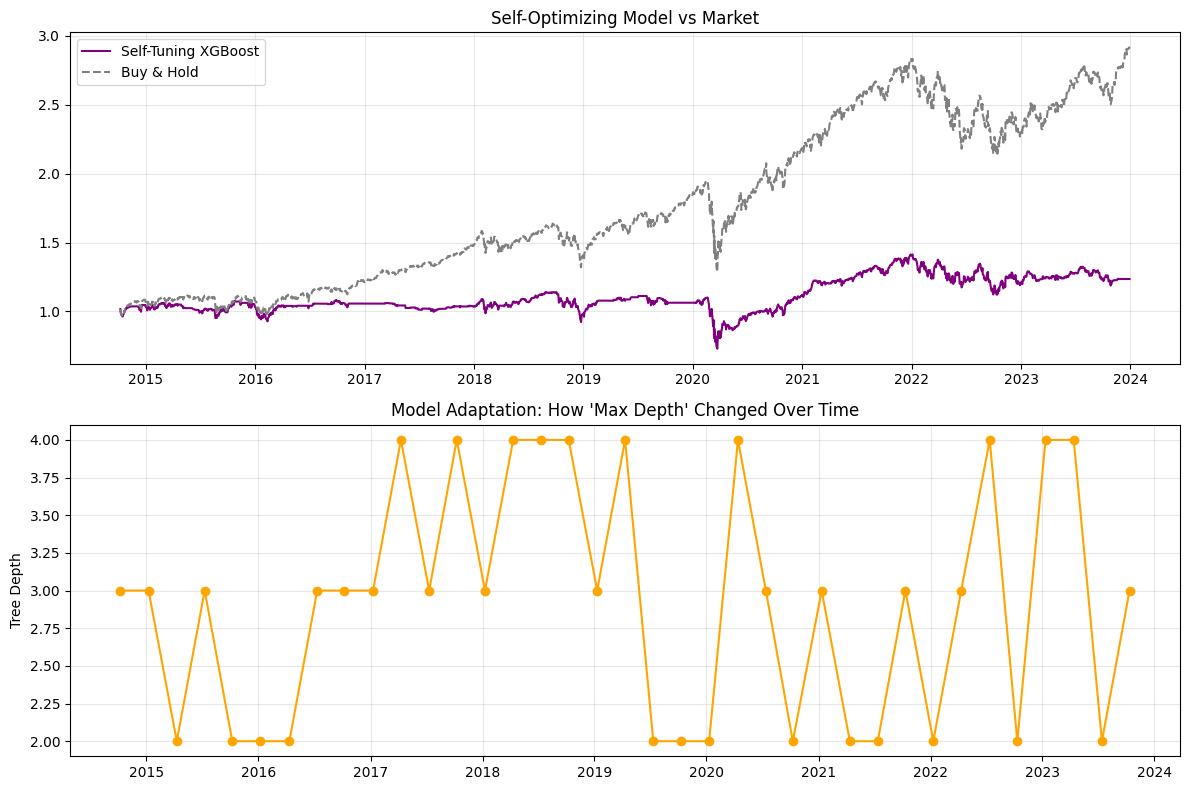

In [ ]:
# --- 4. VISUALIZE ADAPTATION ---
# Did the model change its mind over time?

# Strategy Return
tuned_res['Signal'] = np.where(tuned_res['Prob'] > 0.53, 1, 0) # Higher threshold for tuned model
tuned_res['Strat_Ret'] = tuned_res['Signal'] * tuned_res['Return']
cum_tuned = np.exp(tuned_res['Strat_Ret'].cumsum())
cum_spy = np.exp(tuned_res['Return'].cumsum())

plt.figure(figsize=(12, 8))

# Subplot 1: Returns
plt.subplot(2, 1, 1)
plt.plot(cum_tuned, label='Self-Tuning XGBoost', color='purple')
plt.plot(cum_spy, label='Buy & Hold', color='gray', linestyle='--')
plt.title("Self-Optimizing Model vs Market")
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: Parameter Evolution
# Let's plot how 'max_depth' changed over time
plt.subplot(2, 1, 2)
plt.plot(params_log.index, params_log['Params'].apply(lambda x: x['max_depth']), marker='o', linestyle='-', color='orange')
plt.title("Model Adaptation: How 'Max Depth' Changed Over Time")
plt.ylabel("Tree Depth")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# FEATURE IMPORTANCE STABILITY ANALYSIS

/tmp/ipython-input-1719622799.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start='2015-01-01', end='2024-01-01', progress=False)


Tracking feature evolution...


<Figure size 1200x600 with 0 Axes>

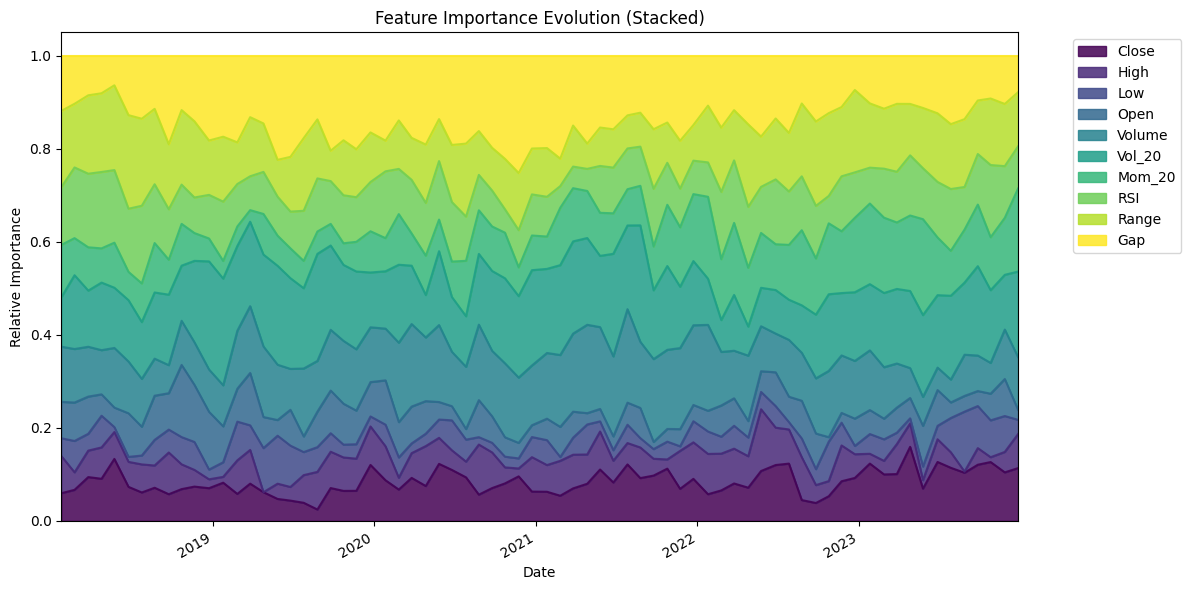

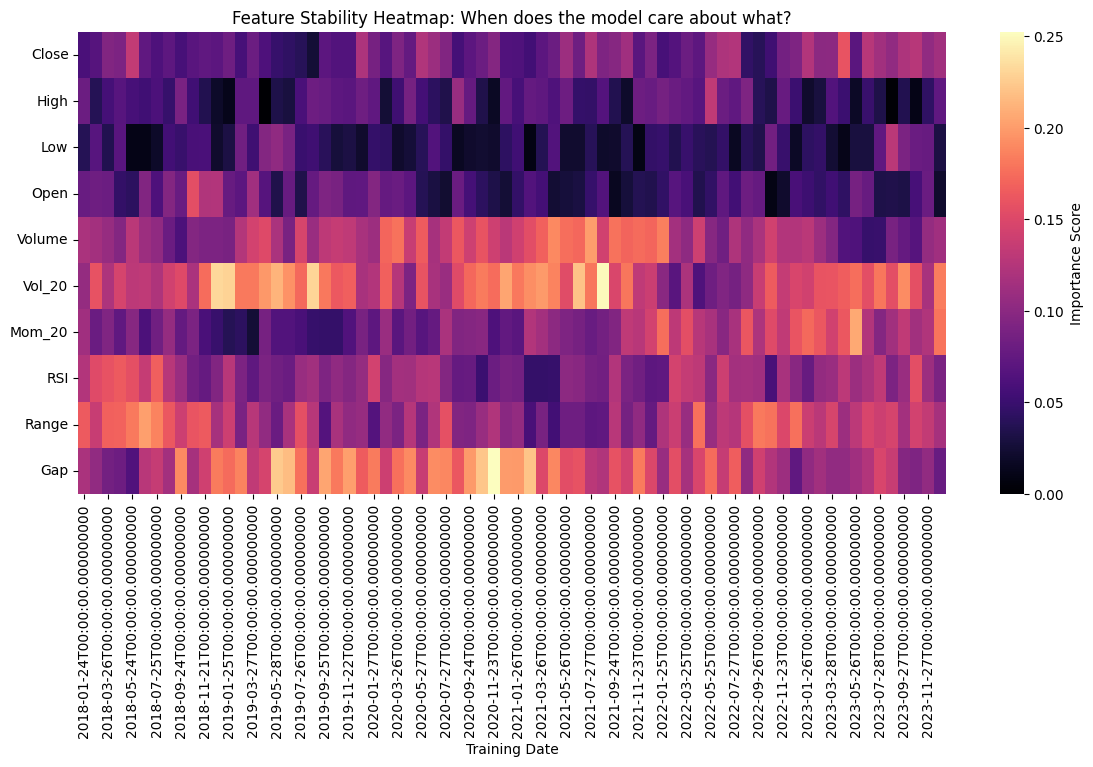

In [ ]:
# --- 1. DATA SETUP (Recap) ---
ticker = 'SPY'
df = yf.download(ticker, start='2015-01-01', end='2024-01-01', progress=False)
if isinstance(df.columns, pd.MultiIndex): df.columns = df.columns.get_level_values(0)

# Features
df['Log_Ret'] = np.log(df['Close'] / df['Close'].shift(1))
df['Vol_20'] = df['Log_Ret'].rolling(20).std()
df['Mom_20'] = df['Close'].pct_change(20)
df['RSI'] = 100 - (100 / (1 + df['Log_Ret'].diff().clip(lower=0).rolling(14).mean() / abs(df['Log_Ret'].diff().clip(upper=0).rolling(14).mean())))
df['Range'] = (df['High'] - df['Low']) / df['Close']
df['Gap'] = (df['Open'] - df['Close'].shift(1)) / df['Close'].shift(1)

# Target
df['Target'] = np.where(df['Log_Ret'].shift(-1) > 0, 1, 0)
df.dropna(inplace=True)

# --- 2. THE FEATURE TRACKER ENGINE ---
def track_feature_stability(data, train_window=500, step_size=63):
    feature_history = []
    dates = []

    # Define features to track (exclude targets)
    feature_cols = [c for c in data.columns if c not in ['Target', 'Log_Ret']]

    print("Tracking feature evolution...")

    for i in range(train_window, len(data), step_size):
        # Window
        train_data = data.iloc[i-train_window : i]
        date = data.index[i]

        X = train_data[feature_cols]
        y = train_data['Target']

        # Fit Model
        model = XGBClassifier(n_estimators=50, max_depth=2, eval_metric='logloss', random_state=42)
        model.fit(X, y)

        # Save Importance
        # We use 'Total Gain' - the most relevant metric for structural importance
        importance = model.get_booster().get_score(importance_type='total_gain')

        # XGBoost returns a dict with only used features, so we must fill missing ones with 0
        row = {k: importance.get(k, 0) for k in feature_cols}
        feature_history.append(row)
        dates.append(date)

    # Convert to DataFrame
    importance_df = pd.DataFrame(feature_history, index=dates)

    # Normalize per row (so percentages sum to 100% for clearer visualization)
    importance_df = importance_df.div(importance_df.sum(axis=1), axis=0)

    return importance_df

# --- 3. RUN ANALYSIS ---
imp_df = track_feature_stability(df, train_window=750, step_size=21) # Step every month

# --- 4. VISUALIZATION ---

# PLOT 1: Stacked Area Chart (The "Evolution")
plt.figure(figsize=(12, 6))
imp_df.plot.area(figsize=(12, 6), colormap='viridis', alpha=0.85)
plt.title("Feature Importance Evolution (Stacked)")
plt.ylabel("Relative Importance")
plt.xlabel("Date")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.margins(0, 0)
plt.tight_layout()
plt.show()

# PLOT 2: Heatmap (The "Regime Map")
plt.figure(figsize=(14, 6))
sns.heatmap(imp_df.T, cmap='magma', cbar_kws={'label': 'Importance Score'})
plt.title("Feature Stability Heatmap: When does the model care about what?")
plt.xlabel("Training Date")
plt.show()

# KELLY CRITERION

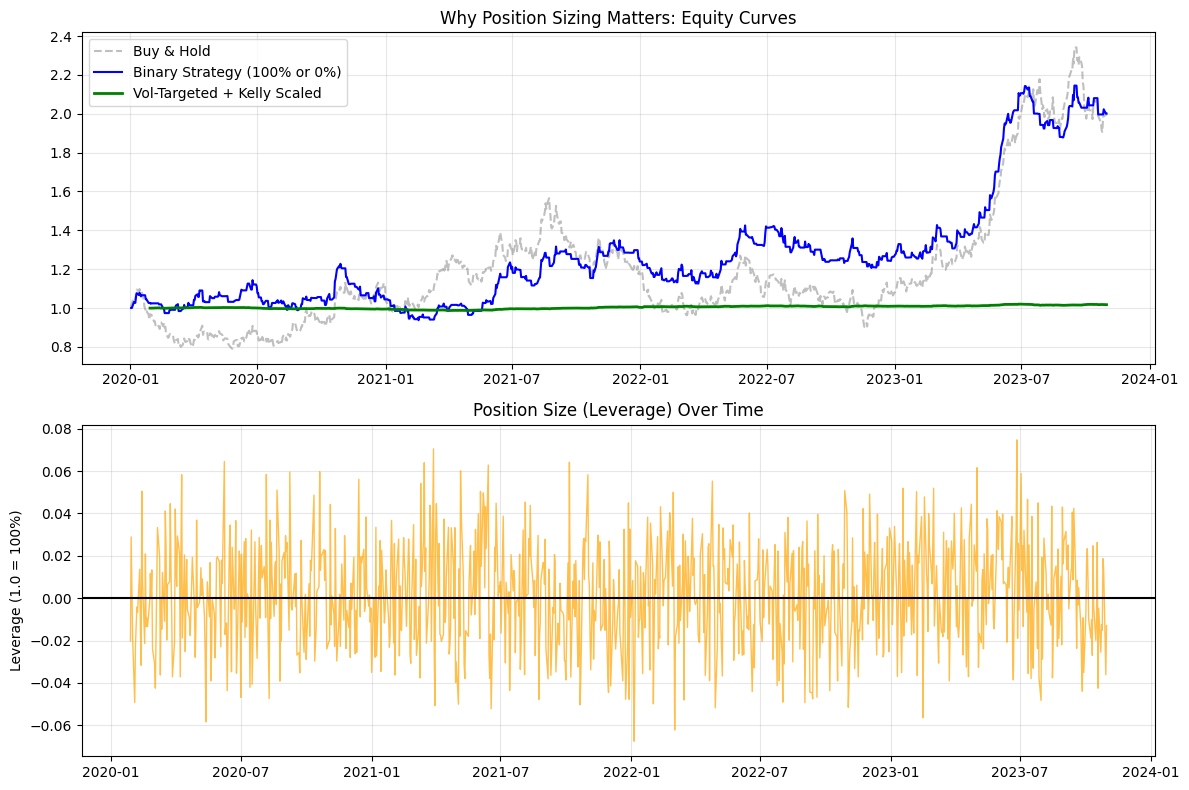

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. SIMULATE MODEL OUTPUTS ---
# Let's assume we have the output from our previous Walk-Forward XGBoost
# Dates, Actual Returns, and Model Probability of "Up"
np.random.seed(42)
dates = pd.date_range(start='2020-01-01', periods=1000, freq='B')
actual_returns = np.random.normal(0.0005, 0.02, 1000) # Daily returns (mean 0.05%, vol 2%)
model_probs = np.random.uniform(0.45, 0.55, 1000) + (actual_returns * 2) # correlated probabilities (skill)
model_probs = np.clip(model_probs, 0, 1)

df_sim = pd.DataFrame({
    'Return': actual_returns,
    'Prob_Up': model_probs
}, index=dates)

# --- 2. POSITION SIZING LOGIC ---

# A. RAW SIGNAL (The "Junior" Approach)
# If Prob > 50%, go 100% Long. Else 100% Cash.
df_sim['Pos_Raw'] = np.where(df_sim['Prob_Up'] > 0.5, 1.0, 0.0)

# B. VOLATILITY TARGETING (The "Hedge Fund" Approach)
# Goal: Keep portfolio volatility constant (e.g., 15% annualized).
# If market is wild, bet smaller. If market is calm, bet bigger.
TARGET_VOL = 0.15
df_sim['Realized_Vol'] = df_sim['Return'].rolling(20).std() * np.sqrt(252)
# Vol Scaler = Target / Current Vol
df_sim['Vol_Scaler'] = TARGET_VOL / df_sim['Realized_Vol']
# Cap leverage at 2.0x to prevent blowing up
df_sim['Vol_Scaler'] = df_sim['Vol_Scaler'].clip(upper=2.0)

# C. KELLY CRITERION (The "Gambler's" Edge)
# Fraction = Edge / Odds
# Continuous Approx: f = (Mean_Ret / Variance) * Probability_Score
# Simplified for Directional Models: f = (2 * p - 1)
# This scales size linearly: 50% prob -> 0% size. 100% prob -> 100% size.
df_sim['Kelly_Fraction'] = (2 * df_sim['Prob_Up'] - 1)
# Kelly is aggressive, usually we take "Half Kelly"
df_sim['Pos_Kelly'] = df_sim['Kelly_Fraction'] * 0.5

# --- 3. COMBINED STRATEGY (Smart Kelly) ---
# We combine Conviction (Kelly) with Risk Control (Vol Target)
# Position = Kelly_Score * Vol_Scaler
df_sim['Pos_Final'] = df_sim['Pos_Kelly'] * df_sim['Vol_Scaler']

# --- 4. BACKTEST CURVES ---
df_sim['Strat_Raw'] = df_sim['Pos_Raw'].shift(1) * df_sim['Return']
df_sim['Strat_Final'] = df_sim['Pos_Final'].shift(1) * df_sim['Return']

cum_raw = (1 + df_sim['Strat_Raw']).cumprod()
cum_final = (1 + df_sim['Strat_Final']).cumprod()
cum_market = (1 + df_sim['Return']).cumprod()

# --- 5. VISUALIZATION ---
plt.figure(figsize=(12, 8))

# Equity Curves
plt.subplot(2, 1, 1)
plt.plot(cum_market, label='Buy & Hold', color='gray', linestyle='--', alpha=0.5)
plt.plot(cum_raw, label='Binary Strategy (100% or 0%)', color='blue')
plt.plot(cum_final, label='Vol-Targeted + Kelly Scaled', color='green', linewidth=2)
plt.title("Why Position Sizing Matters: Equity Curves")
plt.legend()
plt.grid(True, alpha=0.3)

# Leverage/Position Usage
plt.subplot(2, 1, 2)
plt.plot(df_sim['Pos_Final'], color='orange', alpha=0.7, linewidth=1)
plt.axhline(0, color='black', linestyle='-')
plt.title("Position Size (Leverage) Over Time")
plt.ylabel("Leverage (1.0 = 100%)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()